In [1]:
from kiwipiepy import Kiwi
from wordcloud import WordCloud as wc
import random
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

In [5]:
import os

input_dir = "../크롤링 텍스트파일 모음/"
output_file = "merged_reviews.txt"

encodings = ["utf-8", "cp949", "euc-kr"]

with open(output_file, "w", encoding="utf-8") as outfile:
    for filename in os.listdir(input_dir):
        if filename.endswith(".txt"):
            file_path = os.path.join(input_dir, filename)

            text = None
            for enc in encodings:
                try:
                    with open(file_path, "r", encoding=enc) as infile:
                        text = infile.read()
                    break
                except UnicodeDecodeError:
                    continue

            if text is None:
                print(f"⚠️ 인코딩 실패: {filename}")
                continue

            outfile.write(f"\n===== {filename} =====\n")
            outfile.write(text)
            outfile.write("\n")

print("텍스트 파일 병합 완료")


텍스트 파일 병합 완료


In [2]:
with open("merged_reviews.txt", "r", encoding="utf-8") as f:
    content = f.read()

In [3]:
len(content)

15495852

In [ ]:

# ===============================
# 1. Kiwi 초기화 및 데이터 로드
# ===============================
kiwi = Kiwi()
# 앞서 병합하여 content 변수에 저장했다고 가정합니다.
# content = "여기에 병합된 모든 텍스트가 들어있음..."

# ===============================
# 2. 형태소 분석 및 N-gram 생성 함수
# ===============================
def extract_keywords(text):
    # Kiwi를 통한 형태소 분석 (명사 N, 형용사 VA, 동사 VV 위주 추출)
    result = kiwi.analyze(text)
    
    words = []
    for res in tqdm(result):
        tokens = res[0]
        # 일반명사(NNG), 고유명사(NNP), 어근(XR) 추출
        # 형용사(VA)와 동사(VV)의 어간도 포함하려면 추가 가능
        extracted = [t.form for t in tokens if t.tag in ['NNG', 'NNP', 'XR', 'VA', 'VV']]
        words.extend(extracted)
        
    # 2-grams 생성 (단어 두 개가 붙어 나오는 경우: '연결' + '안됨')
    bigrams = []
    for res in tqdm(result):
        tokens = res[0]
        for i in range(len(tokens) - 1):
            # 두 단어의 조합이 의미 있는 태그일 때만 결합
            if tokens[i].tag.startswith('N') and tokens[i+1].tag in ['NNG', 'VA', 'VV', 'MAG']:
                bigrams.append(f"{tokens[i].form} {tokens[i+1].form}")
                
    return words + bigrams

all_tokens = extract_keywords(content)



In [ ]:
# ===============================
# 3. ThinQ 부정 키워드 및 제외 단어 설정
# ===============================
theme_keywords = [
    '연결', '연동', '페어링', '끊김', '접속', '등록', '인식', '와이파이', 'wifi', '오프라인',
    '느림', '렉', '로딩', '튕김', '무거움', '응답', '지연', '업데이트', '불편', '복잡', 
    '어렵', '직관', '시인성', 'UI', '디자인', '찾기', '번거로움', '오류', '버그', '실패', 
    '안됨', '멈춤', '삭제', '재설치', '로그인', '인증', '광고', '알림', '권한', '실망'
]

exclude_words = ['하다', '있다', '되다', '보기', '사용', '로그인', '씽큐'] # 분석에 무의미한 단어 추가



In [ ]:
# ===============================
# 4. 빈도 계산 + 필터링 (부정 테마 키워드 매칭)
# ===============================
word_counts = Counter(all_tokens)
final_counts = {}

for word, count in tqdm(word_counts.items()):
    if word not in exclude_words and len(word) > 1: # 1글자 제외
        # 2-gram이나 단어에 부정 키워드가 포함되어 있는지 확인
        if any(theme in word for theme in theme_keywords):
            final_counts[word] = count



In [ ]:
# ===============================
# 5. 시각화 (LG 컬러 테마)
# ===============================
lg_colors = ["#A50034", "#2B2B2B", "#4A4A4A", "#6A6A6A"]
def lg_color_func(*args, **kwargs):
    return random.choice(lg_colors)

wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/malgun.ttf', # 폰트 경로 확인 필수
    background_color='white',
    width=1200,
    height=1200,
    max_words=200,
    relative_scaling=0.2,
    color_func=lg_color_func
).generate_from_frequencies(final_counts)

# ===============================
# 6. 저장 및 출력
# ===============================
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('thinq_negative_bigram_cloud.png', dpi=300)
plt.show()

In [39]:
# 사용자 정의함수를 활용하여 형태소 분석 후에 특정 품사만 담는 코드를 작성!
def tokenize_review(s):
    token = kiwi.tokenize(s)
    result = [t.form for t in token if t.tag in ['NNP',NNG','VA','VV']]
    return result

In [40]:
tokenize_review(content[:100])

['앱', '카페', '데이터', '스마트', '장만', '모델명', '박스', '호환', '쓰']

In [21]:
from collections import Counter

In [29]:
from wordcloud import WordCloud as wc
import random
import matplotlib.pyplot as plt

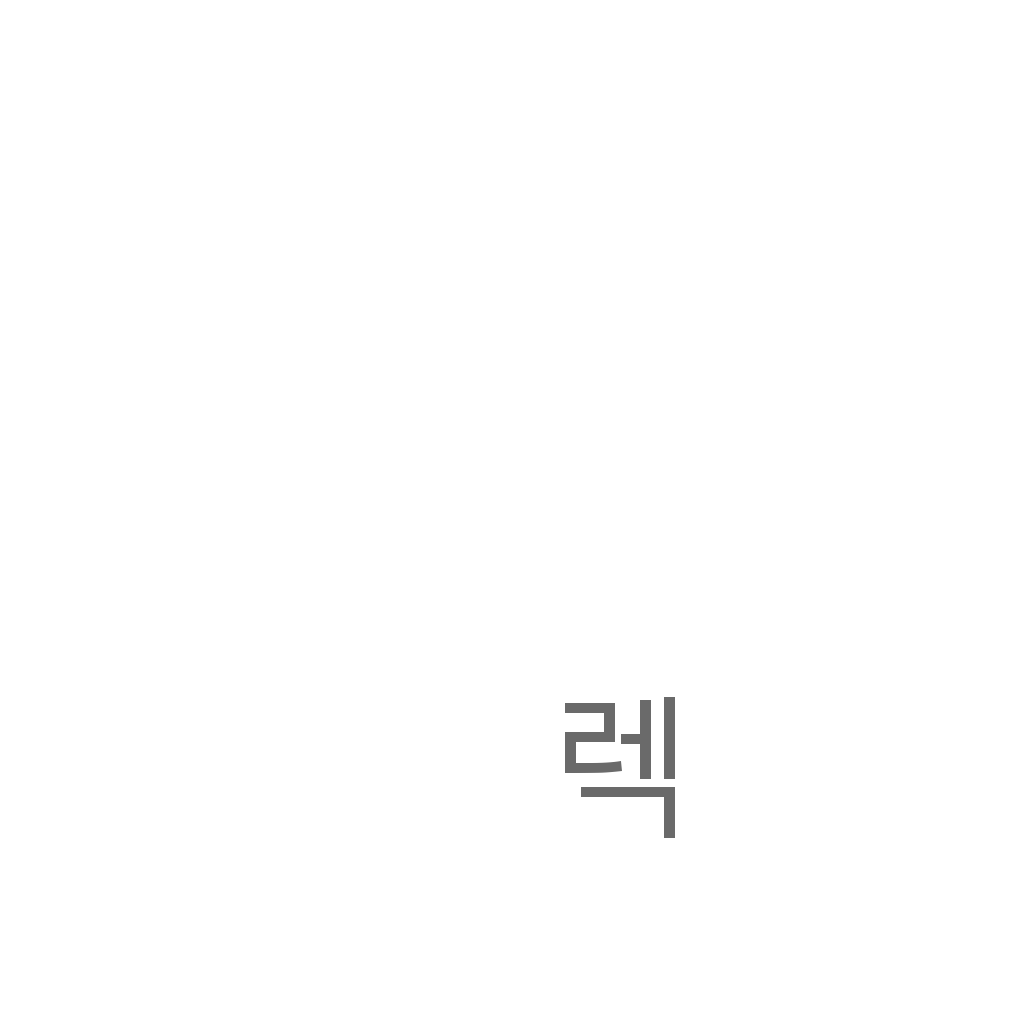

In [30]:
# ===============================
# 4. ThinQ 부정 주제 앵커 키워드
# ===============================
theme_keywords = [
    # 연결 및 연동 문제
    '연결', '연동', '페어링', '끊김', '접속', '등록', '인식', '와이파이', 'wifi', '오프라인',
    # 속도 및 안정성
    '느림', '렉', '로딩', '튕김', '무거움', '응답', '지연', '업데이트', '무한',
    # 사용성 및 UI
    '불편', '복잡', '어렵', '직관적', '시인성', 'UI', '디자인', '찾기', '번거로움',
    # 기능 오류 및 버그
    '오류', '버그', '실패', '안됨', '멈춤', '삭제', '재설치', '로그인', '인증', '팅김',
    # 기타 불만 사항
    '광고', '알림', '권한', '실망', '최악', '힘듦', '문의', '고객센터'
]

# (가정) 전처리된 단어 리스트 'words'가 있다고 가정합니다.
# words = ['연결이', '너무', '느림', '앱이', '자꾸', '튕김', '불편해요', ...]

# ===============================
# 5. 빈도 계산 + ThinQ 부정 의미 필터링
# ===============================
# exclude_words는 이미 정의되어 있다고 가정합니다.
word_counts = Counter(content)
final_counts = {}

for word, count in word_counts.items():
    if any(theme in word for theme in theme_keywords):
        final_counts[word] = count

# ===============================
# 6. LG 컬러 (AI 피드백: 강조를 위해 기존 색상 유지)
# ===============================
lg_colors = ["#A50034", "#2B2B2B", "#4A4A4A", "#6A6A6A"]

def lg_color_func(*args, **kwargs):
    return random.choice(lg_colors)

# ===============================
# 7. 워드클라우드 생성
# ===============================
wordcloud = wc(
    font_path='C:/Windows/Fonts/malgun.ttf',  # 맥 사용 시 'AppleGothic'
    background_color='white',
    width=1000,
    height=1000,
    max_words=200,            # 부정 키워드 특성상 너무 많으면 중복되므로 조정
    max_font_size=150,
    min_font_size=10,
    relative_scaling=0.2,
    prefer_horizontal=0.8,    # 가로 읽기 편하도록 비율 조정
    color_func=lg_color_func,
    margin=2
).generate_from_frequencies(final_counts)

# ===============================
# 8. 시각화 및 저장
# ===============================
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show() # 확인용
# plt.savefig('thinq_negative_wordcloud.png', dpi=300, bbox_inches='tight')

In [31]:
counter = Counter(content)